In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os

# Example n3: 2D pin

# 1. Materials

In [2]:
fuel = openmc.Material(name='UO2 fuel')
fuel.set_density('g/cm3', 10.5)
fuel.add_element('U', 1.0, enrichment=4.5)
fuel.add_element('O', 2.0)

gap = openmc.Material(name='Helium gap')
gap.set_density('g/cm3', 0.001)
gap.add_element('He', 1.0)

clad = openmc.Material(name='Zircaloy')
clad.set_density('g/cm3', 6.55)
clad.add_element('Zr', 1.0)

water = openmc.Material(name='Water')
water.set_density('g/cm3', 0.75)
water.add_element('H', 2.0)
water.add_element('O', 1.0)
water.add_s_alpha_beta('c_H_in_H2O')

materials = openmc.Materials([fuel, gap, clad, water])
materials.export_to_xml()

# 2. Geometry

In [3]:
# Dimensions (cm)
r_fuel = 0.39 
r_gap = 0.40
r_clad = 0.475

# PITCH!
pitch = 1.26

# Cylinders
fuel_cyl = openmc.ZCylinder(r=r_fuel)
gap_cyl = openmc.ZCylinder(r=r_gap)
clad_cyl = openmc.ZCylinder(r=r_clad)

left = openmc.XPlane(x0=-pitch/2, boundary_type='reflective') 
right = openmc.XPlane(x0=+pitch/2, boundary_type='reflective')
bottom = openmc.YPlane(y0=-pitch/2, boundary_type='reflective') 
top = openmc.YPlane(y0=+pitch/2, boundary_type='reflective') 

# Universe
fuel_region = -fuel_cyl
gap_region = +fuel_cyl & -gap_cyl
clad_region = +gap_cyl & -clad_cyl
water_region = +clad_cyl & +left & -right & +bottom & -top
                            
fuel_cell = openmc.Cell(fill=fuel, region=fuel_region)
gap_cell = openmc.Cell(fill=gap, region=gap_region)
clad_cell = openmc.Cell(fill=clad, region=clad_region)
water_cell = openmc.Cell(fill=water, region=water_region)

root_universe = openmc.Universe(cells=[fuel_cell, gap_cell, clad_cell, water_cell])
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

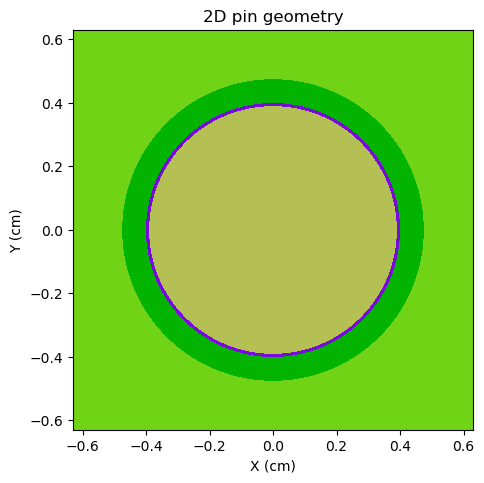

In [4]:
# Create the plot
fig = geometry.plot(basis='xy', origin=(0, 0, 0), width=(pitch, pitch), pixels=(400, 400), color_by='material')

# Set custom x and y labels
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('2D pin geometry')
plt.savefig("geometry.pdf", format = "pdf", dpi = 300, bbox_inches= "tight")
plt.show()

# 3. Settings

In [5]:
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 100
settings.inactive = 10
settings.particles = 10000

settings.export_to_xml()

# 4. Tallies

In [6]:
tallies = openmc.Tallies()

# Mesh for spatial flux
mesh = openmc.RegularMesh()
mesh.dimension = [30, 30, 1]
mesh.lower_left = [-pitch/2, -pitch/2, -1e32]
mesh.upper_right = [ pitch/2,  pitch/2, 1e32]
mesh_filter = openmc.MeshFilter(mesh)

# Energy filters for thermal and fast
thermal = openmc.EnergyFilter([1e-5, 0.625])
fast = openmc.EnergyFilter([0.625, 20.0e6])

# Energy filters for total range
energy_bins = np.logspace(-5, 7, num=100)  # 100 bins
energy_filter = openmc.EnergyFilter(energy_bins)

# Energy flux in fuel and water
PhiE = openmc.Tally(name=f'PhiE')
PhiE.filters = [energy_filter]
PhiE.scores = ['flux']

# Spatial flux: thermal
PhiXY_th = openmc.Tally(name='PhiXY_th')
PhiXY_th.filters = [mesh_filter, thermal]
PhiXY_th.scores = ['flux']

# Spatial flux: fast
PhiXY_f = openmc.Tally(name='PhiXY_f')
PhiXY_f.filters = [mesh_filter, fast]
PhiXY_f.scores = ['flux']


tallies = openmc.Tallies([PhiE, PhiXY_th, PhiXY_f])
tallies.export_to_xml()

# 5. Run

In [7]:
# Run the simulation and create statepoint file
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [8]:
#os.system(f"mv statepoint.100.h5 sp_{pitch}_cm.h5")

# Postprocessing

In [9]:
sp = openmc.StatePoint('statepoint.100.h5')

In the statepoint there are all the useful information of the simulation

In [10]:
keff = sp.keff

print(f"k-eff = {keff.nominal_value:.5f} +/- {keff.std_dev:.3e}")

k-eff = 1.43327 +/- 8.409e-04


Also, statepoint stores the tally data

/tmp/ipykernel_3399640/3619371052.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


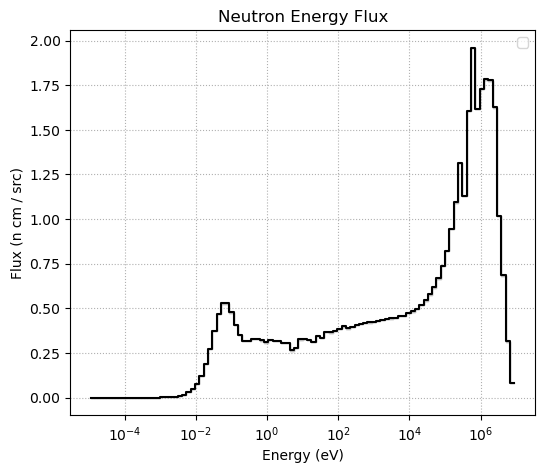

In [11]:
# Energy-dependent flux
PhiE_tally = sp.get_tally(name='PhiE')
PhiE = PhiE_tally.mean.flatten()
UPhiE = PhiE_tally.std_dev.flatten()

# Energy bins (midpoints)
energy_mid = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# Plot the flux spectrum
plt.figure(figsize = (6,5))
plt.step(energy_mid, PhiE, color = "black", where = "pre")
plt.fill_between(energy_mid, PhiE - UPhiE, PhiE - UPhiE, step='pre', color='black', alpha=0.25)

plt.xscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Flux (n cm / src)")
plt.title("Neutron Energy Flux")
plt.grid(True, linestyle = ":")
plt.legend()
#plt.savefig("./phiE_ex2.pdf", format = "pdf", bbox_inches = "tight", dpi = 400)
plt.show()

Space flux

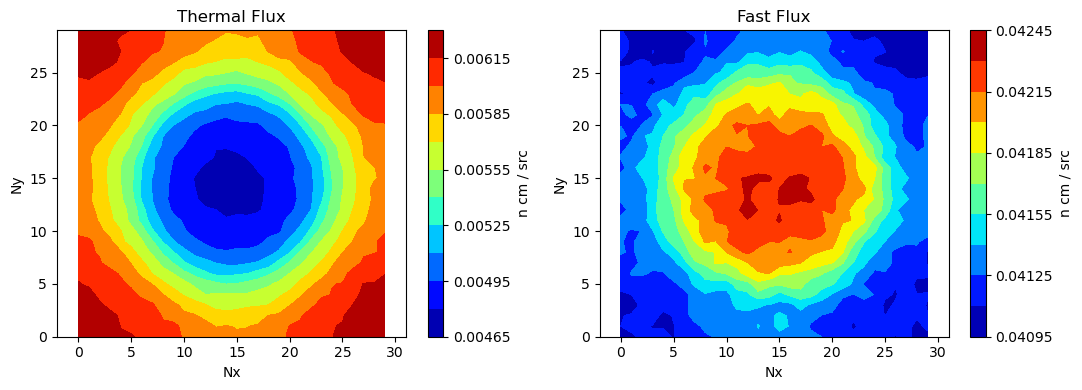

In [12]:
# Plot thermal flux spatial
mesh = sp.get_tally(name='PhiXY_th').filters[0].mesh
flux_thermal = sp.get_tally(name='PhiXY_th').mean.reshape(mesh.dimension[0], mesh.dimension[1])
flux_fast = sp.get_tally(name='PhiXY_f').mean.reshape(mesh.dimension[0], mesh.dimension[1])

fig, ax = plt.subplots(figsize=(11,4), ncols = 2)

c0 = ax[0].contourf(flux_thermal, levels=10, cmap='jet')
ax[0].set_title('Thermal Flux')
ax[0].set_xlabel('Nx')
ax[0].set_ylabel('Ny')
ax[0].axis('equal')
fig.colorbar(c0, label='n cm / src', ax = ax[0])

c1 = ax[1].contourf(flux_fast, levels=10, cmap='jet')
ax[1].set_title('Fast Flux')
ax[1].set_xlabel('Nx')
ax[1].set_ylabel('Ny')
ax[1].axis('equal')
fig.colorbar(c1, label='n cm / src', ax = ax[1])

plt.tight_layout()
fig.savefig("./fluxes2D_pin.pdf", bbox_inches = "tight", dpi = 500, format = "pdf")

# Over/Under moderation

What is the optimal pin pitch? evaluate the k-eff for different pitches and plot them

In [13]:
pitches = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])

keffs = np.zeros(len(pitches))
Ukeffs = np.zeros(len(pitches))

for p in range(len(pitches)):
    sp = openmc.StatePoint(f"./sp_{pitches[p]}_cm.h5")

    keffs[p] = sp.keff.nominal_value
    Ukeffs[p] = sp.keff.std_dev

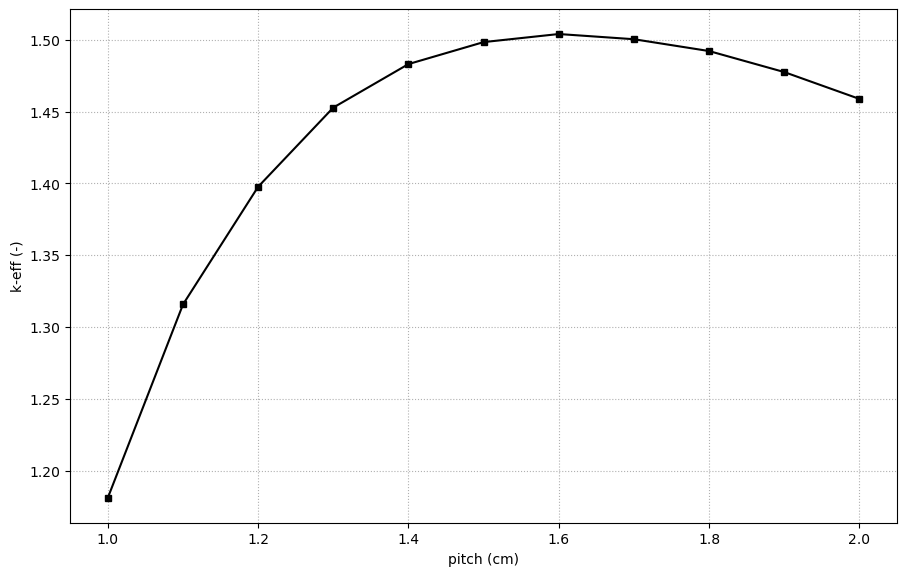

In [14]:
fig, ax = plt.subplots(figsize = (16/1.5, 10/1.5))
ax.errorbar(pitches, keffs, yerr = Ukeffs, color = "black", marker = 's', ms=5)
ax.set_xlabel("pitch (cm)")
ax.set_ylabel("k-eff (-)")
ax.grid(linestyle = ':')
fig.savefig("./keff_pitch.pdf", dpi = 400, format = "pdf", bbox_inches = "tight")